# Basics of Data Flows

At the core of `hyped` lies the `DataFlow` class, which facilitates the construction of flexible and efficient data processing pipelines. Data flows allow you to define and organize a series of transformations that can be applied to datasets, supporting a wide range of use cases from simple processing tasks to complex workflows.

In this tutorial, we will walk you through the essentials of using the `DataFlow` class to create powerful data pipelines. By the end of this tutorial, you will understand how to:

1. Initialize a `DataFlow` and access the source features.
2. Add processing steps to the `DataFlow` instance.
3. Build and apply the `DataFlow` instance to a dataset.

## Imports

To get started, we first need to import the required libraries and modules. These will provide the necessary tools for working with datasets and the `DataFlow` framework.

In [1]:
import datasets
from hyped import DataFlow, plot_data_flow
from hyped.typing import Int, Sequence, Mapping, Len, Annotated

## Creating a Sample Dataset

Next, we'll create a simple dataset using the HuggingFace `datasets` library. This dataset includes a few sample features to work with, making it easy to understand how to build and apply data flows.

In [2]:
ds = datasets.Dataset.from_list(
    [
        {"i": 0, "x": [1, 2]},
        {"i": 1, "x": [2, 3]},
        {"i": 2, "x": [3, 4]},
        {"i": 3, "x": [4, 5]},
    ],
    features=datasets.Features(
        {
            "i": datasets.Value("int32"),
            "x": datasets.Sequence(datasets.Value("int64"))
        }
    )
)

## Initializing a `DataFlow` Instance

The simplest way to initialize a DataFlow instance is to use the dataset features.

In [3]:
flow = DataFlow(ds.features)

By providing the dataset's feature schema, we directly tie the `DataFlow` to the dataset, allowing seamless interaction with its data. This approach is ideal for straightforward use cases where the dataset schema is sufficient to define the flow.

## Understanding `flow.source`

The `source` property of a `DataFlow` instance provides access to the source features, which serve as the input data for your processing pipeline. This is a (potentially nested) object that reflects the structure of your input dataset.

**Key Characteristics**:

- It behaves like a Python dictionary, allowing you to access features by their names (keys).
- The source features are dynamically typed based on the dataset schema or the provided mapping class during initialization.

**Accessing Features**

To access specific input features, simply use dictionary-style indexing. For instance:

In [4]:
# Accessing the input feature 'i'
flow.source["i"]

Int32Feature(ref=ConcreteReference(_node_id='2416da6e-c212-cddb-8d88-00160eb686b2', _graph=<hyped.core.graph.DataFlowGraph object at 0x113bcc710>))

If a feature is a sequence, you can further index into it:

In [5]:
# Accessing the first value in the sequence feature 'x'
flow.source["x"][0]  

Int64Feature(ref=ConcreteReference(_node_id='71445abc-2f0d-dac2-4097-acb7a3823bc9', _graph=<hyped.core.graph.DataFlowGraph object at 0x113bcc710>))

This approach makes defining processing pipelines intuitive and Pythonic, as you work directly with the features as you would with a native Python object. In the next section, we’ll explore how to build processing pipelines using these source features.

## Building Processing Pipelines

Defining processing pipelines is as simple and intuitive as performing standard Python operations. You work directly with the `flow.source` features, applying computations and transformations to build the desired outputs.

Suppose you want to compute the sum of the values in the sequence feature `x` and multiply it by the scalar feature `i`. This can be done effortlessly with the following expression:

In [6]:
y = flow.source["i"] * flow.source["x"].sum()

Note that the result `y` is itself a feature, meaning it can be further processed or combined with other features and operations in the pipeline.

In [7]:
z = y * 2

Here, `z` is derived by multiplying the feature `y` with a constant value. This flexibility allows for easy integration of constants into your pipelines.

While using `DataFlow` is simple and Pythonic, it operates under the hood by building a directed graph of processing steps. Essentially, `DataFlow` constructs an **abstract syntax tree (AST)** of the processing pipeline, with nodes representing individual operations or transformations.

To gain insight into the inner workings of your pipeline, you can visualize the flow of data and the operations being performed at each step. This can be easily done using the following function:

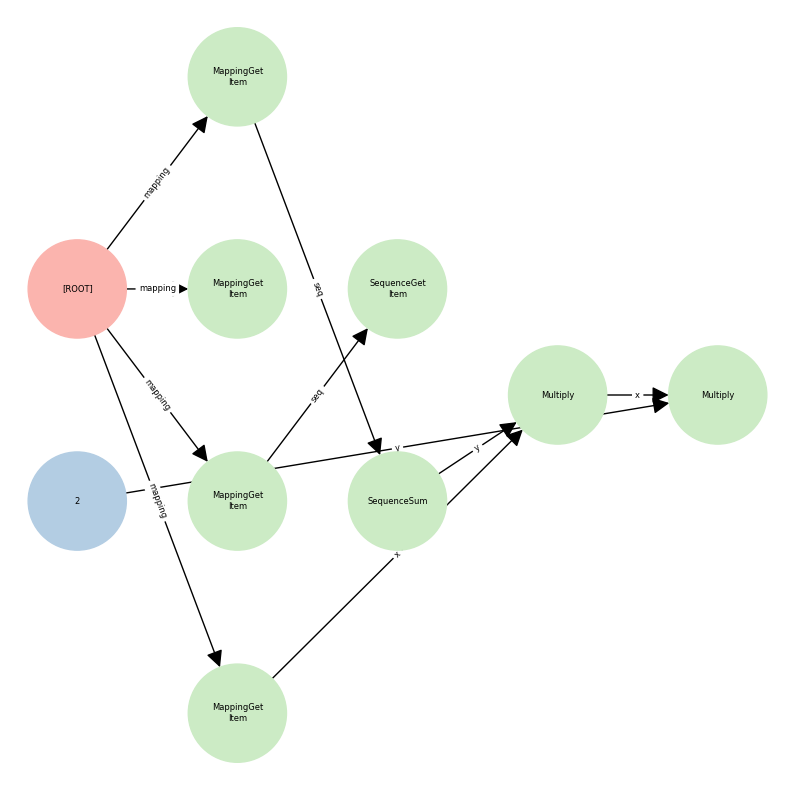

In [8]:
plot_data_flow(flow);

Note how all operations taken so far are represented by a separate node in the AST. This also includes indexing operations (e.g. `flow.source["i"]`).  

## Building the Data Flow

Up until now, we’ve been defining the processing pipeline and visualizing it, but no output has been explicitly defined. The next step is to build the data flow, where we specify the output and prepare the graph for execution. During this step, the data flow is optimized, and unnecessary computations are eliminated.

In the visualized graph, you may notice multiple "dead ends" or nodes that are not directly involved in the final output. The building process takes care of these redundancies and ensures that only the relevant parts of the graph are retained for computation.

To build the data flow, you can use the `build()` method and specify which parts of the pipeline should produce the output.

In [9]:
flow = flow.build(collect={"z": z})

The `collect` argument specifies the output features you want to retain, in this case, `z`. The `build()` function will optimize the graph and include only the necessary nodes required to compute `z`. This can be seen when visualizing the build flow.

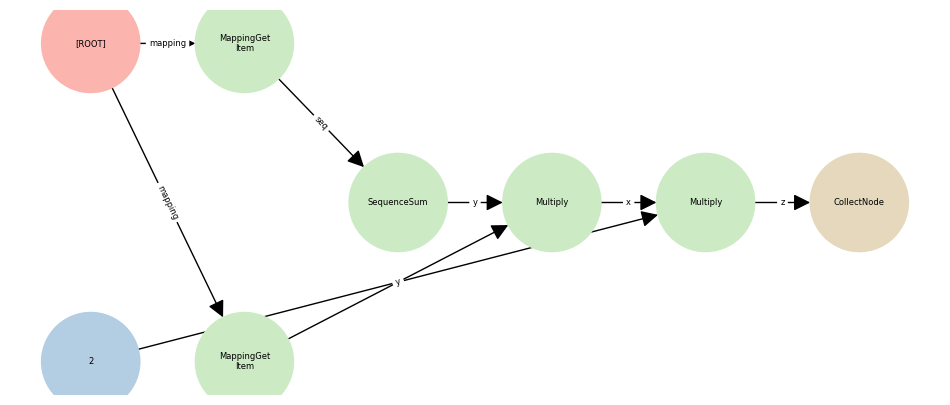

In [10]:
plot_data_flow(flow);

### Applying the Data Flow

Once the data flow has been defined and built, and the output has been specified, the final step is to apply the data flow to a dataset. This is done by passing the dataset to the `apply()` method.

In [11]:
out_ds = flow.apply(ds)

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

This step processes the input dataset `ds` according to the defined pipeline and produces the output dataset `out_ds`.

Note that the features of `out_ds` align with the `collect` argument.

In [12]:
out_ds.to_dict()

{'z': [0, 10, 28, 54]}

## Advanced Usage

In this section, we will explore more advanced features of the`DataFlow` that allow you to build flexible, dataset-independent workflows and perform powerful dataset-wide operations. You’ll learn how to define custom input schema types that provide fine-grained control over your data’s structure, enabling you to design reusable and dynamic data flows.

Let's start by exploring how to define custom input schemas and proceed to dataset aggregation with `DataFlow`.

### Custom Input Schema Definition

In the previous section, we covered basic initialization by using the dataset's feature schema or a simple custom mapping. Now, we’ll dive deeper into creating and using custom input schemas. This allows you to define reusable, dataset-independent data flows that can be shared across various datasets, making your data pipeline more flexible and efficient.

**1. Defining a Dustom Input Schema**

A custom input schema allows you to define your data structure more explicitly. By subclassing the `Mapping` class, you can specify the expected data types and additional constraints. This helps ensure the schema is well-defined, making your data flow more predictable and type-safe.

In [13]:
# Defining a custom input schema
class Inputs(Mapping):
    i: Int
    x: Annotated[Sequence[Int], Len(2)]

Here, the `Inputs` schema specifies that `i` should be an integer, and `x` should be a sequence of exactly two integers.

**2. Initializing the DataFlow from the Custom Schema**

You can initialize the `DataFlow` instance using this custom `Inputs` schema. This will infer the feature types from the schema, making it easier to map to a variety of datasets without specifying the features upfront.

In [14]:
flow = DataFlow[Inputs]()  
print("Inferred Data Type of feature 'i':", flow.source['i'].dtype)

Inferred Data Type of feature 'i': Int64


In this case, the `DataFlow` is initialized with the `Inputs` schema. Note that generic types will be concretized, i.e. the type of `i` is inferred as `Int64` based on the generic `Int` annotation.

**3. Validation and Dataset Feature Matching**

When you initialize a `DataFlow` with both the custom schema and dataset features, the framework will perform validation to ensure that the dataset features align with the schema. If the dataset features don’t match the expected types in the schema, an error will be raised.

In [15]:
flow = DataFlow[Inputs](ds.features)  
print("Inferred Data Type of feature 'i':", flow.source['i'].dtype)

Inferred Data Type of feature 'i': Int32


In this case, the generic type `Int` is concretized based on the concrete dataset features, leading to `i` being of type `Int32` this time.

### Dataset-Wide Aggregation

The `DataFlow` class also provides the ability to perform dataset-wide aggregation, which is useful for computing global statistics or processing the entire dataset in a more holistic way. You can easily compute summary statistics such as the sum, mean for any feature in the dataset. Here’s how to aggregate the values of the feature `i` across the whole dataset:

In [16]:
# Create a new DataFlow instance
flow = DataFlow(ds.features)

# Aggregate the values of 'i' over the whole dataset
i_sum = flow.source["i"].sum()

In this example, `i_sum` computes the sum of the values of feature `i` across the entire dataset. You can apply similar aggregation functions for other statistics like mean.

**2. Applying the Aggregation to the Dataset**

Once the aggregation is defined, you can apply it to the dataset using the `apply` method. This allows you to compute the desired aggregate values and access them alongside the transformed dataset.

In [17]:
# Apply the aggregation to the dataset
out_ds, aggregates = flow.apply(ds, collect=flow.source, aggregate={"sum(i)": i_sum})

# Inspect the aggregates
print(aggregates)

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

{'sum(i)': 6}


The `apply` method performs the aggregation and collects the results. The output dataset `out_ds` contains the transformed data, while the aggregates dictionary holds the computed aggregation values. In this case, aggregates will contain the sum of feature `i`.

### Multi-Dataset Aggregation

In some cases, you may want to use the `build` method to construct the data flow with predefined aggregations and then access those aggregates as a property of the `DataFlow` instance. This approach is slightly different from the above, as the aggregates are retained and updated across multiple calls to `apply`.

Use the `build` method to prepare the DataFlow with the aggregation operation. This will allow you to `apply` the aggregation across the dataset, but the results will be stored as part of the `DataFlow` instance and accessible through its `aggregates` property.

In [18]:
# Create a new DataFlow instance
flow = DataFlow(ds.features)

# Aggregate the values of 'i' over the whole dataset
i_sum = flow.source["i"].sum()

# Build the DataFlow with aggregation
flow = flow.build(collect=flow.source, aggregate={"sum(i)": i_sum})

The `build` method sets up the flow and specifies the aggregation operation (in this case, the sum of i). The aggregation state will be retained and updated as you apply the flow to the dataset.

Once the flow is built, you can call the `apply` method to process the dataset. The aggregates will be updated with each call to `apply`, and you can access the current state of the aggregates at any point using the aggregates property.

In [19]:
# Apply the DataFlow to the dataset
_ = flow.apply(ds)

# Print the aggregates after the first apply
print("First apply: ", flow.aggregates)

# Apply the DataFlow to the dataset again
_ = flow.apply(ds)

# Print the aggregates after the second apply
print("Second apply:", flow.aggregates)

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

First apply:  {'sum(i)': 6}


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Second apply: {'sum(i)': 12}


## Conclusion

In this tutorial, we've walked through how to define and build data processing pipelines using the `DataFlow` framework. From initializing the data flow and working with features to optimizing the computation graph and applying the flow to a dataset, each step allows you to easily transform and process data in a clean and efficient way.

To recap, the entire process boils down to just a few lines of code:

In [20]:
flow = DataFlow(ds.features)
flow = flow.build(collect={"z": 2 * (flow.source["i"] * flow.source["x"].sum())})
out_ds = flow.apply(ds)

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

This approach simplifies complex workflows, making it possible to define, optimize, and execute data transformations efficiently. With just a few steps, you can go from raw data to the processed output, all while ensuring that your pipeline is both scalable and easily maintainable.